# Chromium Pre-process
https://www.10xgenomics.com/datasets/pbm-cs-from-a-healthy-donor-whole-transcriptome-analysis-1-1-standard-4-0-0

In [1]:
%load_ext autoreload
%autoreload 2
%env ANYWIDGET_HMR=1

env: ANYWIDGET_HMR=1


In [2]:
import scanpy as sc
import celldega as dega

/Users/feni/Documents/celldega/dega/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 1.14.5 when it was built against 1.14.6, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [3]:
adata = sc.read_10x_mtx('data/chromium_data/chromium_pbmc_healthy-donor/filtered_feature_bc_matrix')
adata

AnnData object with n_obs × n_vars = 6574 × 36601
    var: 'gene_ids', 'feature_types'

In [4]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [5]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [6]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [7]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

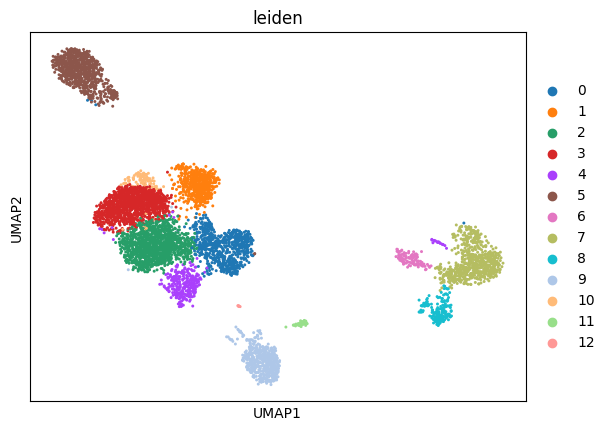

In [8]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
# Using the igraph implementation and a fixed number of iterations can be significantly faster, especially for larger datasets
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)
sc.pl.umap(adata, color=["leiden"])

In [9]:
adata

AnnData object with n_obs × n_vars = 6565 × 18314
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [10]:
path_landscape_files = 'data/landscape_files/chromium_pbmc_healthy-donor'

# Make LandscapeFiles

In [11]:
# dega.pre.make_chromium_from_anndata(adata, path_landscape_files)

In [12]:
server_address = dega.viz.get_local_server()

In [14]:
path_landscape_files = 'data/landscape_files/chromium_pbmc_healthy-donor'
base_url = f'http://localhost:{server_address}/{path_landscape_files}'
landscape = dega.viz.Landscape(
    technology='Chromium',
    base_url = base_url,
    height=600, 
    adata=adata, 
    cell_attr=['leiden'],
    ini_zoom=-4.5,
    ini_x=4000,
    ini_y=5000
)
# landscape

/var/folders/8d/jxpy9rd10j7fp2rcj_s5sz3c0000gq/T/ipykernel_44500/2172255112.py:3: UserWarning: Transformation matrix not found at http://localhost:62031/data/landscape_files/chromium_pbmc_healthy-donor/micron_to_image_transform.csv. Using identity.
  landscape = dega.viz.Landscape(


In [15]:
mat = dega.clust.Matrix(adata)
mat.filter(axis='row', by='mean', num=10000)
mat.filter(axis='row', by='var', num=5000)
mat.downsample_to(category='leiden')
mat.norm(axis='row', by='zscore')
mat.cluster()

cgm = dega.Clustergram(matrix=mat, width=500, height=500)

/Users/feni/Documents/celldega/src/celldega/clust/matrix.py:194: UserWarning: Large matrix (6565 x 18314). Consider filtering.
  self.load_adata(data, col_attr=col_attr, row_attr=row_attr)


In [17]:
dega.viz.landscape_clustergram(landscape, cgm)

In [18]:
adata.write_h5ad('data/chromium_data/chromium_pbmc_healthy-donor/adata.h5ad')